# Importing Libraries and Loading Dataset

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('car data.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'car data.csv'

# Dataset Overview

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head(5))

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Get information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


None

In [ ]:
# Generate descriptive statistics for numerical columns
display(df.describe())

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
# Check for missing values
display(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

# Feature Engineering: Create Car Age Feature

In [ ]:
df['Car_Age'] = 2026 - df['Year']

# Drop Year column because Car_Age is more useful
df.drop('Year', axis=1, inplace=True)

# Display updated dataset
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


# Feature Engineering and Preprocessing


In [ ]:
# Reload the dataset to ensure a fresh start for feature engineering
df = pd.read_csv('car data.csv')

# Drop Car_Name column
df.drop('Car_Name', axis=1, inplace=True)

# Calculate 'Car_Age' from 'Year'
current_year = 2024  # Assuming the current year for calculation
df['Car_Age'] = current_year - df['Year']

# Drop the original 'Year' column
df = df.drop('Year', axis=1)

# Drop the 'Owner' column due to skewed distribution
df = df.drop('Owner', axis=1)

# Display the updated DataFrame head
display(df.head())

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,10


# Prepare for One-Hot Encoding.

In [ ]:
# Get unique values for 'Fuel_Type', 'Selling_type', and 'Transmission'
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']
missing_cols = [col for col in categorical_cols if col not in df.columns]

if missing_cols:
    print(f"Error: The following categorical columns are missing from the DataFrame: {missing_cols}. Please ensure previous data preprocessing steps have been executed correctly.")
else:
    print(f"Unique Fuel Types: {df['Fuel_Type'].unique()}")
    print(f"Unique Selling Types: {df['Selling_type'].unique()}")
    print(f"Unique Transmission Types: {df['Transmission'].unique()}")

Unique Fuel Types: ['Petrol' 'Diesel' 'CNG']
Unique Selling Types: ['Dealer' 'Individual']
Unique Transmission Types: ['Manual' 'Automatic']


# Correlation Heatmap Between Features

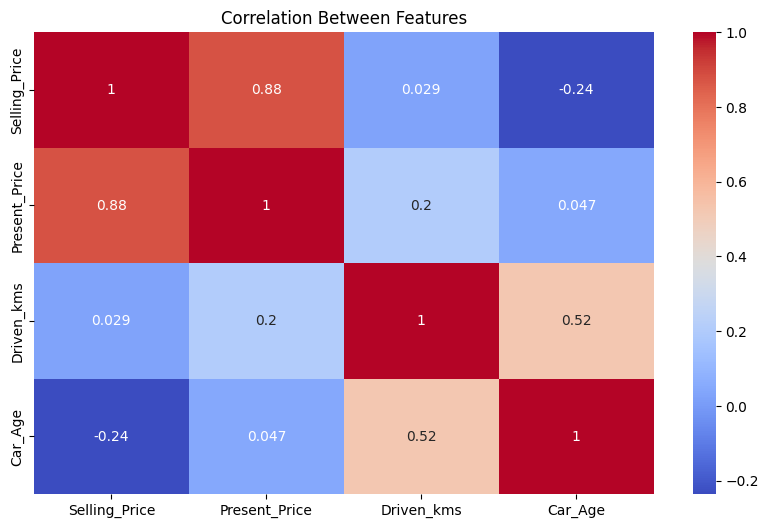

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Features')

plt.show()

# One-Hot Encoding

In [ ]:
# Apply one-hot encoding to 'Fuel_Type', 'Selling_type', and 'Transmission'
categorical_cols_to_encode = ['Fuel_Type', 'Selling_type', 'Transmission']

# Check if all columns exist in the DataFrame before encoding
missing_cols_for_encoding = [col for col in categorical_cols_to_encode if col not in df.columns]

if missing_cols_for_encoding:
    print(f"Error: Cannot perform one-hot encoding. The following columns are missing from the DataFrame: {missing_cols_for_encoding}.")
    print("Please ensure that the DataFrame 'df' has been correctly prepared by running all preceding feature engineering and preprocessing cells.")
else:
    df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

    # Display the first 5 rows of the DataFrame after one-hot encoding
    display(df.head(5))

,Selling_Price,Present_Price,Driven_kms,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,10,False,True,False,True
1,4.75,9.54,43000,11,True,False,False,True
2,7.25,9.85,6900,7,False,True,False,True
3,2.85,4.15,5200,13,False,True,False,True
4,4.60,6.87,42450,10,True,False,False,True


# Data Splitting and Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling (excluding one-hot encoded columns and Car_Age if it's already scaled conceptually)
numerical_cols = ['Present_Price', 'Driven_kms', 'Car_Age']

# Scale numerical features in both training and testing sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data splitting and feature scaling complete.")

Data splitting and feature scaling complete.


# Model Training and Evaluation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5

print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared: 0.85
Mean Absolute Error (MAE): 1.19
Mean Squared Error (MSE): 3.36
Root Mean Squared Error (RMSE): 1.83


# Horizontal Bar Plot

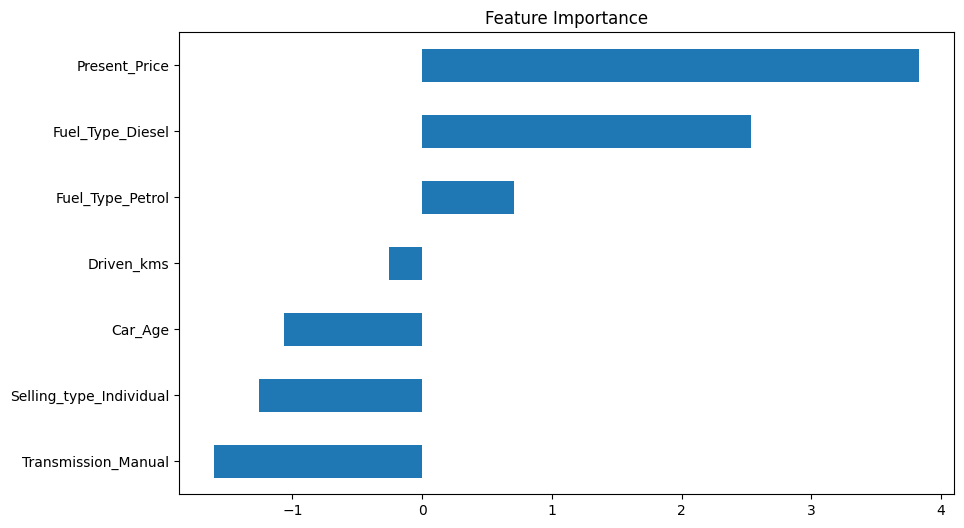

In [ ]:
# Feature Importance Analysis

importance = model.coef_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Feature Importance')

plt.show()

# Creating Sample Car Data for Prediction

In [ ]:
# Example features for a new car (Car_Name is not needed after dropping)
new_car_data = {
    'Year': [2015], # Manufacturing Year
    'Present_Price': [5.5], # Present ex-showroom price (in lakhs)
    'Driven_kms': [5000], # Kilometers driven
    'Fuel_Type': ['Petrol'],
    'Selling_type': ['Dealer'],
    'Transmission': ['Manual'],
    'Owner': [0] # Number of previous owners (0 for first owner)
}

new_car_df = pd.DataFrame(new_car_data)
display(new_car_df)

,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2015,5.5,5000,Petrol,Dealer,Manual,0


## Real-World Applications


Used car shops can find the correct car price.

Online car websites can set prices automatically.

Insurance companies can estimate car value.

Buyers and sellers can make better decisions about car prices.